In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
 
from sklearn.tree import DecisionTreeClassifier, export_text, plot_tree
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report
)

## 1. Завантаження та попередня обробка даних


In [3]:
df = sns.load_dataset('titanic')
df = df.rename(columns={
    'survived': 'Survived',
    'pclass': 'Pclass',
    'sex': 'Sex',
    'age': 'Age',
    'sibsp': 'SibSp',
    'parch': 'Parch',
    'fare': 'Fare',
    'embarked': 'Embarked'
})
columns_needed = ['Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked']
df = df[columns_needed]
 
print(" Датасет завантажено ")
print(f"Розмір датасету: {df.shape[0]} рядків, {df.shape[1]} колонок")
df.head()

 Датасет завантажено 
Розмір датасету: 891 рядків, 8 колонок


,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,71.2833,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,male,35.0,0,0,8.0500,S


In [4]:
print("=" * 50)
print("ЗАГАЛЬНА ІНФОРМАЦІЯ ПРО ДАТАСЕТ:")
print("=" * 50)
df.info()
 
print("\n" + "=" * 50)
print("ПРОПУЩЕНІ ЗНАЧЕННЯ:")
print("=" * 50)
missing = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Кількість пропущених': missing, '% від загального': missing_pct})
print(missing_df[missing_df['Кількість пропущених'] > 0])
 
print("\nСтатистика датасету:")
df.describe()

ЗАГАЛЬНА ІНФОРМАЦІЯ ПРО ДАТАСЕТ:
<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Pclass    891 non-null    int64  
 2   Sex       891 non-null    str    
 3   Age       714 non-null    float64
 4   SibSp     891 non-null    int64  
 5   Parch     891 non-null    int64  
 6   Fare      891 non-null    float64
 7   Embarked  889 non-null    str    
dtypes: float64(2), int64(4), str(2)
memory usage: 60.9 KB

ПРОПУЩЕНІ ЗНАЧЕННЯ:
          Кількість пропущених  % від загального
Age                        177             19.87
Embarked                     2              0.22

Статистика датасету:


,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [7]:
df = df.copy()
df['Age'] = df['Age'].fillna(df['Age'].median())
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])
df['Fare'] = df['Fare'].fillna(df['Fare'].median())
print("Пропущені значення заповнено!")
print("\nПеревірка після заповнення:")
print(df.isnull().sum())

Пропущені значення заповнено!

Перевірка після заповнення:
Survived    0
Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Embarked    0
dtype: int64


In [8]:
df['Sex'] = df['Sex'].map({'male': 0, 'female': 1})
df['Embarked'] = df['Embarked'].map({'S': 0, 'C': 1, 'Q': 2})
print("Категоріальні ознаки перетворено у числовий формат!")
print("\nПерші 5 рядків після перетворення:")
print(df.head())
print("\nТипи даних:")
print(df.dtypes)

Категоріальні ознаки перетворено у числовий формат!

Перші 5 рядків після перетворення:
   Survived  Pclass  Sex   Age  SibSp  Parch     Fare  Embarked
0         0       3    0  22.0      1      0   7.2500         0
1         1       1    1  38.0      1      0  71.2833         1
2         1       3    1  26.0      0      0   7.9250         0
3         1       1    1  35.0      1      0  53.1000         0
4         0       3    0  35.0      0      0   8.0500         0

Типи даних:
Survived      int64
Pclass        int64
Sex           int64
Age         float64
SibSp         int64
Parch         int64
Fare        float64
Embarked      int64
dtype: object


## 2. Поділ даних на навчальну та тестову вибірки

In [9]:
X = df.drop('Survived', axis=1)
y = df['Survived']
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y 
)
print("Дані розділено на навчальну та тестову вибірку")
print(f"\nРозмір навчальної вибірки (X_train): {X_train.shape}")
print(f"Розмір тестової вибірки  (X_test):  {X_test.shape}")
print(f"\nРозподіл класів у навчальній вибірці:")
print(y_train.value_counts())
print(f"\nРозподіл класів у тестовій вибірці:")
print(y_test.value_counts())

Дані розділено на навчальну та тестову вибірку

Розмір навчальної вибірки (X_train): (712, 7)
Розмір тестової вибірки  (X_test):  (179, 7)

Розподіл класів у навчальній вибірці:
Survived
0    439
1    273
Name: count, dtype: int64

Розподіл класів у тестовій вибірці:
Survived
0    110
1     69
Name: count, dtype: int64


## 3. Побудова класифікатора на основі дерев рішень

In [10]:
model = DecisionTreeClassifier(
    max_depth=5,      
    random_state=42
)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print("Модель дерева рішень навчена")
print(f"\nГлибина дерева:     {model.get_depth()}")
print(f"Кількість вузлів:   {model.tree_.node_count}")
print(f"Кількість листків:  {model.get_n_leaves()}")
 
print("\nПерші 10 прогнозів vs реальні значення:")
comparison = pd.DataFrame({
    'Реальне': y_test.values[:10],
    'Прогноз': y_pred[:10]
})
print(comparison)

Модель дерева рішень навчена

Глибина дерева:     5
Кількість вузлів:   45
Кількість листків:  23

Перші 10 прогнозів vs реальні значення:
   Реальне  Прогноз
0        0        0
1        0        0
2        1        0
3        0        0
4        1        1
5        1        0
6        1        1
7        0        1
8        0        0
9        0        0


## 4. Оцінювання якості класифікації

In [11]:
accuracy  = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall    = recall_score(y_test, y_pred)
f1        = f1_score(y_test, y_pred)
 
print("=" * 45)
print("МЕТРИКИ ЯКОСТІ КЛАСИФІКАЦІЇ:")
print("=" * 45)
print(f"  Accuracy  (Точність):    {accuracy:.4f}  ({accuracy*100:.2f}%)")
print(f"  Precision (Влучність):   {precision:.4f}  ({precision*100:.2f}%)")
print(f"  Recall    (Повнота):     {recall:.4f}  ({recall*100:.2f}%)")
print(f"  F1-score  (F1-міра):     {f1:.4f}  ({f1*100:.2f}%)")
print("=" * 45)

МЕТРИКИ ЯКОСТІ КЛАСИФІКАЦІЇ:
  Accuracy  (Точність):    0.7821  (78.21%)
  Precision (Влучність):   0.7679  (76.79%)
  Recall    (Повнота):     0.6232  (62.32%)
  F1-score  (F1-міра):     0.6880  (68.80%)


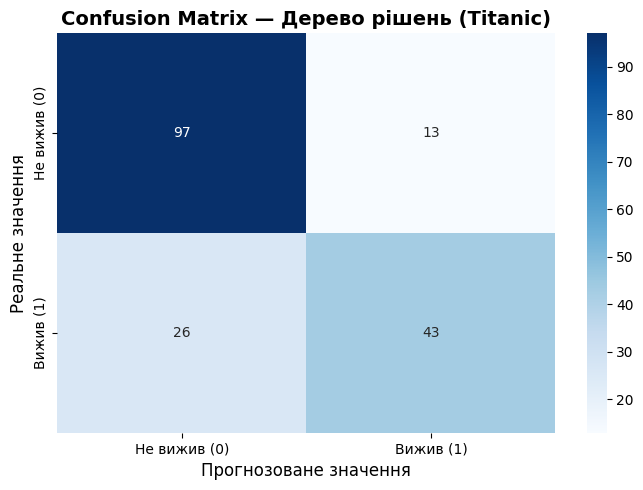


Confusion Matrix:
  TN (правильно: не вижив) = 97
  FP (хибна тривога)       = 13
  FN (пропуск виживших)    = 26
  TP (правильно: вижив)    = 43


In [12]:
cm = confusion_matrix(y_test, y_pred)
 
plt.figure(figsize=(7, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Не вижив (0)', 'Вижив (1)'],
    yticklabels=['Не вижив (0)', 'Вижив (1)']
)
plt.title('Confusion Matrix — Дерево рішень (Titanic)', fontsize=14, fontweight='bold')
plt.ylabel('Реальне значення', fontsize=12)
plt.xlabel('Прогнозоване значення', fontsize=12)
plt.tight_layout()
plt.show()
 
print(f"\nConfusion Matrix:")
print(f"  TN (правильно: не вижив) = {cm[0][0]}")
print(f"  FP (хибна тривога)       = {cm[0][1]}")
print(f"  FN (пропуск виживших)    = {cm[1][0]}")
print(f"  TP (правильно: вижив)    = {cm[1][1]}")

In [13]:
print("=" * 55)
print("ДЕТАЛЬНИЙ ЗВІТ КЛАСИФІКАЦІЇ (classification_report):")
print("=" * 55)
print(classification_report(
    y_test, y_pred,
    target_names=['Не вижив (0)', 'Вижив (1)']
))

ДЕТАЛЬНИЙ ЗВІТ КЛАСИФІКАЦІЇ (classification_report):
              precision    recall  f1-score   support

Не вижив (0)       0.79      0.88      0.83       110
   Вижив (1)       0.77      0.62      0.69        69

    accuracy                           0.78       179
   macro avg       0.78      0.75      0.76       179
weighted avg       0.78      0.78      0.78       179



АНАЛІЗ БАЛАНСУ КЛАСІВ:
  Не вижили (0): 549 пасажирів (61.62%)
  Вижили    (1): 342 пасажирів (38.38%)


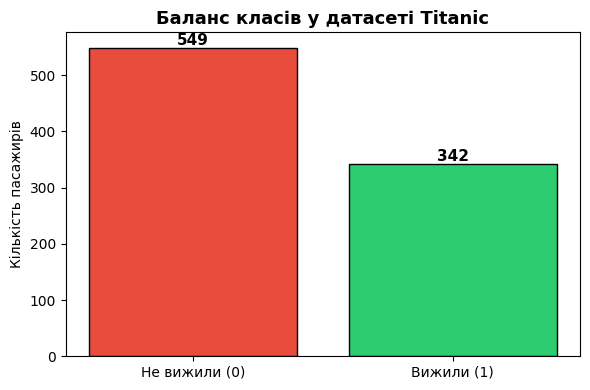


ВИСНОВОК щодо метрик:
  • Класи НЕ збалансовані (~62% не вижили, ~38% вижили).
  • Accuracy може бути оманливою при незбалансованих класах —
    модель, що завжди передбачає "0", дала б ~62% accuracy.
  • Для цього завдання найбільш інформативними є:
      - Recall    — важливо не пропустити виживших
      - F1-score  — баланс між Precision та Recall
      - Precision — щоб не помилково відносити загиблих до виживших



In [14]:
print("=" * 50)
print("АНАЛІЗ БАЛАНСУ КЛАСІВ:")
print("=" * 50)
 
class_counts = y.value_counts()
class_pct    = (y.value_counts(normalize=True) * 100).round(2)
 
print(f"  Не вижили (0): {class_counts[0]} пасажирів ({class_pct[0]}%)")
print(f"  Вижили    (1): {class_counts[1]} пасажирів ({class_pct[1]}%)")
 
plt.figure(figsize=(6, 4))
bars = plt.bar(
    ['Не вижили (0)', 'Вижили (1)'],
    class_counts.values,
    color=['#E74C3C', '#2ECC71'],
    edgecolor='black'
)
plt.title('Баланс класів у датасеті Titanic', fontsize=13, fontweight='bold')
plt.ylabel('Кількість пасажирів')
for bar, val in zip(bars, class_counts.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
             str(val), ha='center', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()
 
print("""
ВИСНОВОК щодо метрик:
  • Класи НЕ збалансовані (~62% не вижили, ~38% вижили).
  • Accuracy може бути оманливою при незбалансованих класах —
    модель, що завжди передбачає "0", дала б ~62% accuracy.
  • Для цього завдання найбільш інформативними є:
      - Recall    — важливо не пропустити виживших
      - F1-score  — баланс між Precision та Recall
      - Precision — щоб не помилково відносити загиблих до виживших
""")

## 5. Інтерпретація моделі

ВАЖЛИВІСТЬ ОЗНАК (Feature Importance):
  Ознака  Важливість
     Sex    0.530655
  Pclass    0.180404
    Fare    0.124532
     Age    0.118263
Embarked    0.034252
   SibSp    0.011150
   Parch    0.000745


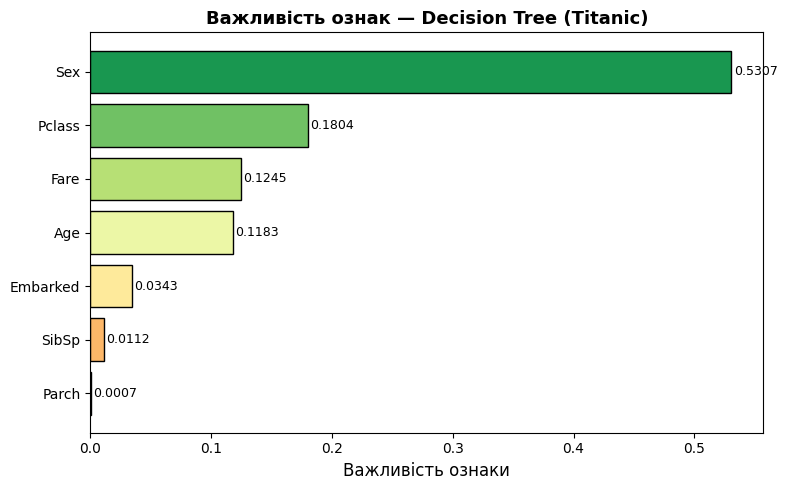


АНАЛІЗ:
  • Sex (Стать) — найважливіша ознака: жінки виживали значно частіше
    ("Жінки та діти — першими").
  • Fare (Вартість квитка) — відображає соціальний статус пасажира.
  • Age (Вік) — молодші пасажири мали вищі шанси на виживання.
  • Pclass (Клас каюти) — пасажири 1-го класу виживали частіше.
  • SibSp, Parch — розмір родини мав менший вплив.
  • Embarked (Порт посадки) — найменший вплив на виживання.



In [15]:
feature_names = X.columns.tolist()
importances   = model.feature_importances_
 
feat_df = pd.DataFrame({
    'Ознака': feature_names,
    'Важливість': importances
}).sort_values('Важливість', ascending=False)
 
print("=" * 45)
print("ВАЖЛИВІСТЬ ОЗНАК (Feature Importance):")
print("=" * 45)
print(feat_df.to_string(index=False))
 
plt.figure(figsize=(8, 5))
colors = plt.cm.RdYlGn(np.linspace(0.2, 0.9, len(feat_df)))
bars = plt.barh(feat_df['Ознака'], feat_df['Важливість'], color=colors[::-1], edgecolor='black')
plt.xlabel('Важливість ознаки', fontsize=12)
plt.title('Важливість ознак — Decision Tree (Titanic)', fontsize=13, fontweight='bold')
plt.gca().invert_yaxis()
for bar, val in zip(bars, feat_df['Важливість']):
    plt.text(val + 0.002, bar.get_y() + bar.get_height()/2,
             f'{val:.4f}', va='center', fontsize=9)
plt.tight_layout()
plt.show()
 
print("""
АНАЛІЗ:
  • Sex (Стать) — найважливіша ознака: жінки виживали значно частіше
    ("Жінки та діти — першими").
  • Fare (Вартість квитка) — відображає соціальний статус пасажира.
  • Age (Вік) — молодші пасажири мали вищі шанси на виживання.
  • Pclass (Клас каюти) — пасажири 1-го класу виживали частіше.
  • SibSp, Parch — розмір родини мав менший вплив.
  • Embarked (Порт посадки) — найменший вплив на виживання.
""")

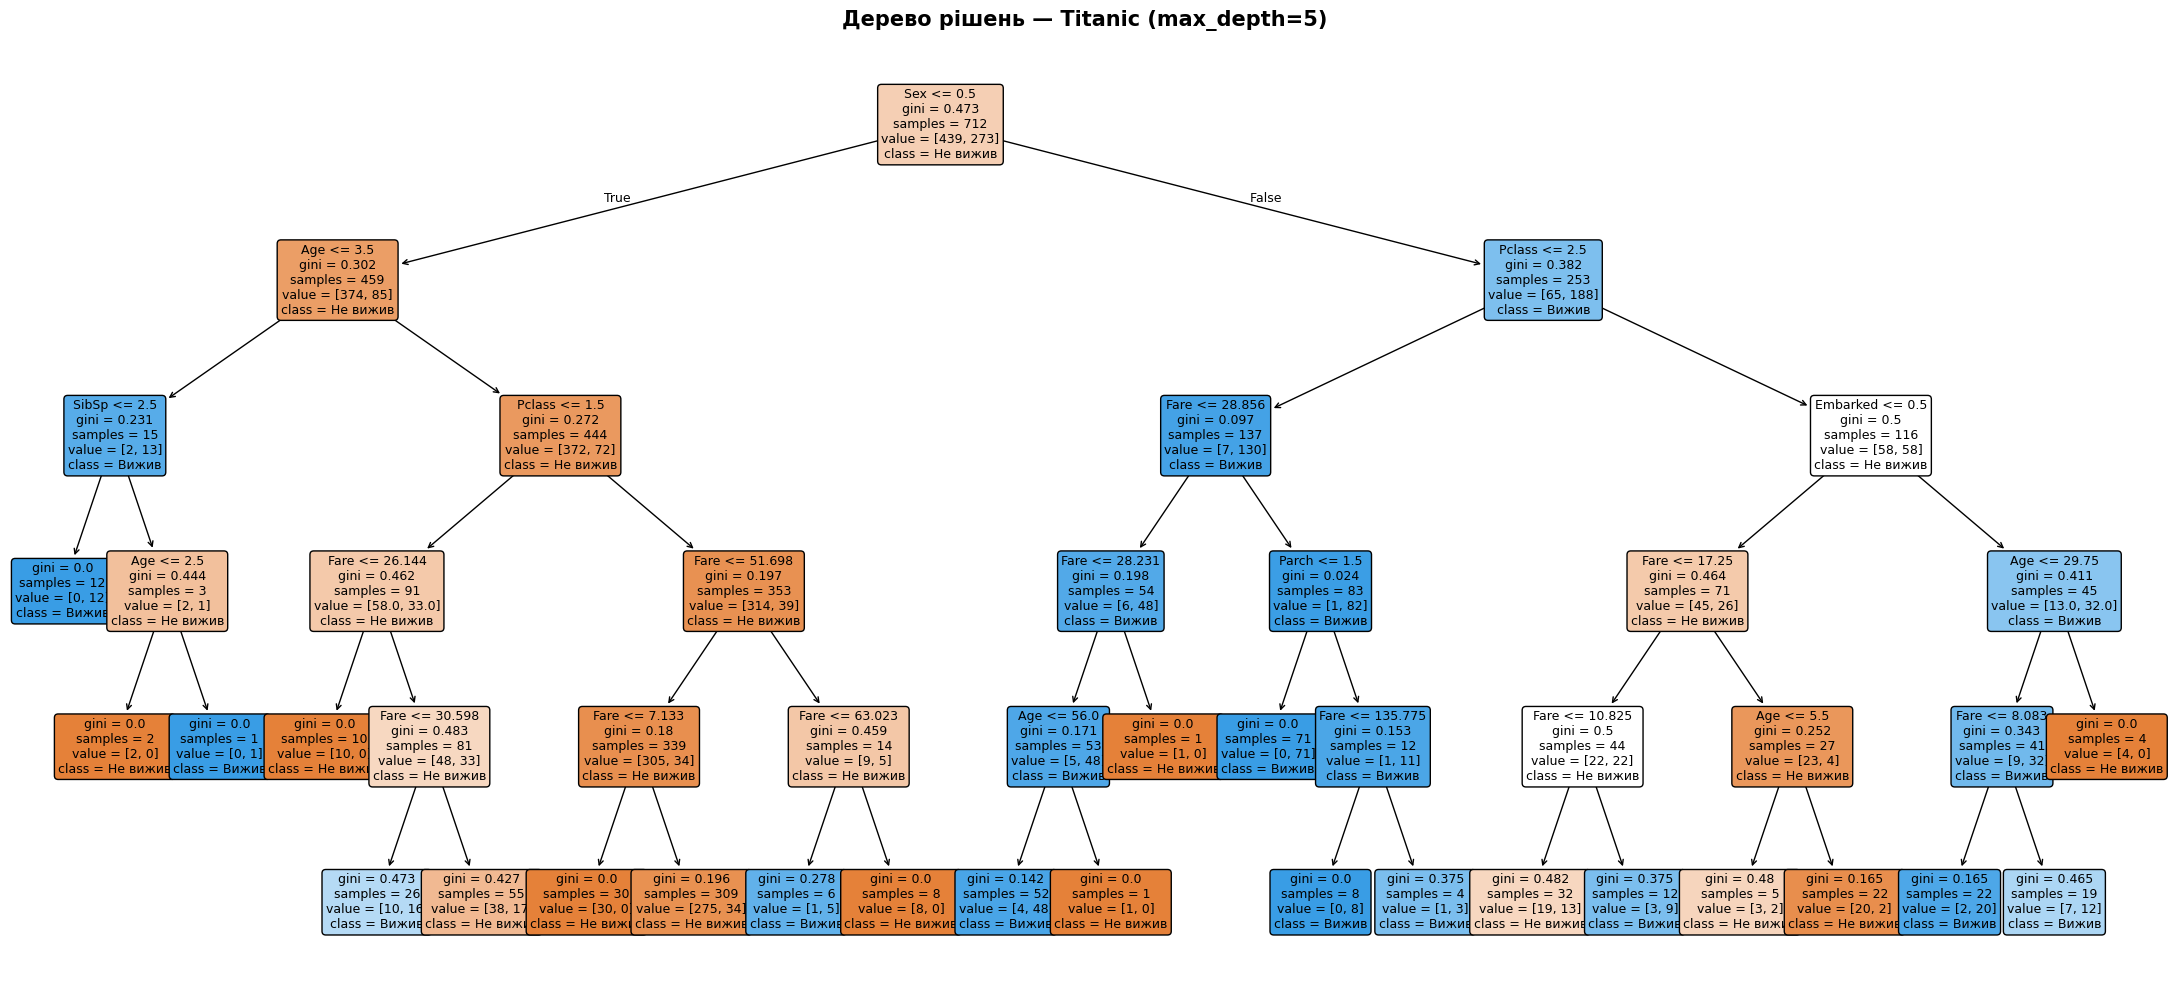

✅ Дерево рішень збережено як 'decision_tree_titanic.png'

ТЕКСТОВЕ ПРЕДСТАВЛЕННЯ ДЕРЕВА (перші 3 рівні):
|--- Sex <= 0.50
|   |--- Age <= 3.50
|   |   |--- SibSp <= 2.50
|   |   |   |--- class: 1
|   |   |--- SibSp >  2.50
|   |   |   |--- Age <= 2.50
|   |   |   |   |--- class: 0
|   |   |   |--- Age >  2.50
|   |   |   |   |--- class: 1
|   |--- Age >  3.50
|   |   |--- Pclass <= 1.50
|   |   |   |--- Fare <= 26.14
|   |   |   |   |--- class: 0
|   |   |   |--- Fare >  26.14
|   |   |   |   |--- truncated branch of depth 2
|   |   |--- Pclass >  1.50
|   |   |   |--- Fare <= 51.70
|   |   |   |   |--- truncated branch of depth 2
|   |   |   |--- Fare >  51.70
|   |   |   |   |--- truncated branch of depth 2
|--- Sex >  0.50
|   |--- Pclass <= 2.50
|   |   |--- Fare <= 28.86
|   |   |   |--- Fare <= 28.23
|   |   |   |   |--- truncated branch of depth 2
|   |   |   |--- Fare >  28.23
|   |   |   |   |--- class: 0
|   |   |--- Fare >  28.86
|   |   |   |--- Parch <= 1.50
|   |   |   | 

In [16]:
plt.figure(figsize=(22, 10))
plot_tree(
    model,
    feature_names=feature_names,
    class_names=['Не вижив', 'Вижив'],
    filled=True,
    rounded=True,
    fontsize=9,
    impurity=True,
    proportion=False
)
plt.title('Дерево рішень — Titanic (max_depth=5)', fontsize=15, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('decision_tree_titanic.png', dpi=150, bbox_inches='tight')
plt.show()
 
print("✅ Дерево рішень збережено як 'decision_tree_titanic.png'")
print("\nТЕКСТОВЕ ПРЕДСТАВЛЕННЯ ДЕРЕВА (перші 3 рівні):")
print("=" * 60)
tree_text = export_text(model, feature_names=feature_names, max_depth=3)
print(tree_text)

In [17]:
print("=" * 55)
print("ПІДСУМОК ЛАБОРАТОРНОЇ РОБОТИ №4")
print("=" * 55)
print(f"  Модель:           DecisionTreeClassifier")
print(f"  Глибина дерева:   {model.get_depth()}")
print(f"  Кількість вузлів: {model.tree_.node_count}")
print(f"  Accuracy:         {accuracy*100:.2f}%")
print(f"  Precision:        {precision*100:.2f}%")
print(f"  Recall:           {recall*100:.2f}%")
print(f"  F1-score:         {f1*100:.2f}%")
print("=" * 55)
print("  Найважливіша ознака для виживання: Sex (Стать)")
print("=" * 55)

ПІДСУМОК ЛАБОРАТОРНОЇ РОБОТИ №4
  Модель:           DecisionTreeClassifier
  Глибина дерева:   5
  Кількість вузлів: 45
  Accuracy:         78.21%
  Precision:        76.79%
  Recall:           62.32%
  F1-score:         68.80%
  Найважливіша ознака для виживання: Sex (Стать)


## ВИСНОВОК 
У ході лабораторної роботи було досліджено задачу класифікації на прикладі датасету Titanic. Проведено попередню обробку даних, побудовано модель дерева рішень та оцінено її якість за допомогою стандартних метрик. Модель показала задовільні результати, однак має труднощі з виявленням усіх виживших пасажирів. Аналіз важливості ознак показав, що найбільший вплив на виживання має стать пасажира.